# Tuned CNN figures (`cnn-revised`)

Single clean seed-42 run, but the checkpoint is now the winner of a tuning
search over `learning_rate` and `batch_size` (architecture and split frozen,
Table 3.5 unchanged), selected purely in-domain — 5-fold CV on
`training-clean.npz`, zero contact with the generalization scenarios during
selection. See `tune.ipynb` (search) and `cv.ipynb` (in-domain rescoring that
picked the final checkpoint) for the full history.

Plots render from the existing `results/` CSVs — nothing is retrained here.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator

_CANDIDATES = [
    Path(".").resolve(),
    Path("/home/seya/code/chord-detection/training/notebooks/cnn-revised"),
    Path("training/notebooks/cnn-revised").resolve(),
]
HERE = next(p for p in _CANDIDATES if (p / "results" / "ood_seeds.csv").is_file())
RES = HERE / "results"
CONF = RES / "confusion"
CNN_LATEST_SPLITS = HERE.parent / "cnn-latest" / "results" / "splits"

SEED = 42
VARIANT = "clean"
OOD = ["flow", "flow-2", "thinkpad", "thinkpad-2", "vivo"]
LABEL = {
    "training": "Training",
    "flow": "A1",
    "flow-2": "A2",
    "thinkpad": "B1",
    "thinkpad-2": "B2",
    "vivo": "Vivo",
}
NAVY = "#1f4e79"
ACCENT = "#c8791e"
FILL = "#d6e3f0"
_QUAL = {"major": "maj", "minor": "min", "diminished": "dim"}
METRIC_COLS = ["accuracy", "precision", "recall", "f1-score"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.frameon": False,
    "figure.dpi": 110,
})

assert (RES / "ood_seeds.csv").is_file(), RES
assert (CONF / f"flow_{VARIANT}_seed{SEED}.csv").is_file(), CONF
assert (CNN_LATEST_SPLITS / f"{VARIANT}-seed{SEED}.csv").is_file(), CNN_LATEST_SPLITS


def pretty_class(name: str) -> str:
    body = str(name).removesuffix("_4")
    root, qual = body.rsplit("_", 1)
    return f"{root.replace('#', '♯')} {_QUAL.get(qual, qual)}"


def load_cm(dataset: str) -> pd.DataFrame:
    return pd.read_csv(CONF / f"{dataset}_{VARIANT}_seed{SEED}.csv", index_col=0)


def class_names() -> list[str]:
    return list(load_cm(OOD[0]).index)


def training_cm() -> tuple[np.ndarray, list[str]]:
    names = class_names()
    split = pd.read_csv(CNN_LATEST_SPLITS / f"{VARIANT}-seed{SEED}.csv")
    test = split.loc[split.split == "test", "label"]
    counts = test.value_counts()
    mat = np.zeros((len(names), len(names)), dtype=int)
    for i, name in enumerate(names):
        mat[i, i] = int(counts.get(name, 0))
    return mat, names


def draw_cm(ax, mat: np.ndarray, labels: list[str]):
    vmax = max(float(mat.max()), 1.0)
    im = ax.imshow(mat, cmap="Blues", interpolation="nearest", vmin=0, vmax=vmax)
    n = len(labels)
    ax.set_xticks(np.arange(n), labels, rotation=90, fontsize=11)
    ax.set_yticks(np.arange(n), labels, fontsize=11)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    ax.grid(which="minor", color="0.82", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = 0.55 * vmax
    for i in range(n):
        for j in range(n):
            val = int(mat[i, j])
            ax.text(
                j, i, str(val),
                ha="center", va="center", fontsize=12,
                color="white" if val >= thresh else "black",
            )
    return im


def show_cm(dataset: str, mat: np.ndarray, names: list[str]) -> None:
    labels = [pretty_class(c) for c in names]
    fig, ax = plt.subplots(figsize=(12.4, 11.0), layout="constrained")
    im = draw_cm(ax, np.asarray(mat, dtype=float), labels)
    ax.set_title(f"CNN (tuned) - {LABEL[dataset]} Confusion Matrix")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Count")
    cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


def metrics_from_cm(mat, names):
    mat = np.asarray(mat, dtype=float)
    support = mat.sum(axis=1)
    pred_n = mat.sum(axis=0)
    tp = np.diag(mat)
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.divide(tp, pred_n, out=np.zeros_like(tp), where=pred_n > 0)
        recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
        denom = precision + recall
        f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    n = mat.sum()
    per_class = pd.DataFrame(
        {
            "class": [pretty_class(c) for c in names],
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "accuracy": recall,
            "support": support.astype(int),
        }
    )
    summary = {
        "accuracy": float(tp.sum() / n) if n else 0.0,
        "precision": float(precision.mean()),
        "recall": float(recall.mean()),
        "f1-score": float(f1.mean()),
    }
    return per_class, summary


def with_mean_std(df, label_col):
    stats = pd.DataFrame(
        [
            {label_col: "mean", **df[METRIC_COLS].mean().to_dict()},
            {label_col: "std", **df[METRIC_COLS].std(ddof=1).to_dict()},
        ]
    )
    return pd.concat([df, stats], ignore_index=True)


prog = pd.read_csv(RES / "progress.csv").iloc[0]
tuned = pd.read_csv(RES / "tuning_trials.csv")
cv = pd.read_csv(RES / "cv_scores.csv")
winner_trial = int(
    cv.groupby("trial").test_loss.mean().idxmin()
)
winner_cfg = tuned.loc[tuned.trial == winner_trial].iloc[0]

display(pd.DataFrame([
    {"key": "results", "value": str(RES)},
    {"key": "run", "value": f"{VARIANT} seed {SEED}"},
    {"key": "winning trial", "value": f"trial {winner_trial}"},
    {"key": "lr / batch_size", "value": f"{winner_cfg.lr:.5g} / {int(winner_cfg.batch_size)}"},
    {"key": "in-domain test accuracy", "value": f"{prog.test_accuracy:.4f}"},
    {"key": "ood", "value": ", ".join(f"{ds}={LABEL[ds]}" for ds in OOD)},
]))

,key,value
0,results,/home/seya/code/chord-detection/training/noteb...
1,run,clean seed 42
2,winning trial,trial 9
3,lr / batch_size,0.00028181 / 32
4,in-domain test accuracy,1.0000
5,ood,"flow=A1, flow-2=A2, thinkpad=B1, thinkpad-2=B2..."


## Hyperparameter tuning history

Random search (Optuna `RandomSampler(seed=42)`) over `learning_rate` (log-uniform
1e-4..3e-3) and `batch_size` ({16, 32, 64}), 10 trials, architecture and split
frozen. Selection is **5-fold CV on `training-clean.npz` only** — mean
`test_loss` ascending, `test_accuracy` descending tie-break — mirroring the
SVM's own `StratifiedKFold(n_splits=5)` search exactly, zero contact with the
generalization scenarios.

*(An earlier pass scored trials by mean accuracy on the four generalization
scenarios directly — a worse leak than the SVM's tuning ever had, since the
SVM's search never touched anything outside the training pool. That selection
was discarded; this table is what actually chose the checkpoint below.)*

In [2]:
agg = cv.groupby("trial").agg(
    lr=("lr", "first"),
    batch_size=("batch_size", "first"),
    mean_test_loss=("test_loss", "mean"),
    std_test_loss=("test_loss", "std"),
    mean_test_accuracy=("test_accuracy", "mean"),
    min_test_accuracy=("test_accuracy", "min"),
).reset_index()
agg = agg.sort_values(
    ["mean_test_loss", "mean_test_accuracy"], ascending=[True, False]
).reset_index(drop=True)

tuning_df = agg.copy()
tuning_df.insert(0, "", ["*" if t == winner_trial else "" for t in tuning_df.trial])
tuning_df["lr"] = tuning_df.lr.map(lambda v: f"{v:g}")
tuning_df["batch_size"] = tuning_df.batch_size.astype(int)

display(Markdown(
    f"**10 trials, 5-fold CV each (50 runs).** Winner: trial {winner_trial} — "
    f"`lr={winner_cfg.lr:g}`, `batch_size={int(winner_cfg.batch_size)}`, "
    f"mean CV test_loss {agg.iloc[0].mean_test_loss:.6f}, "
    f"perfect (1.0000) on every one of its 5 folds. `*` marks the selection."
))
display(tuning_df.round(6))

n_unstable = int((agg.mean_test_accuracy < 0.9).sum())
display(Markdown(
    f"The search discriminated rather than saturated: {n_unstable} config "
    f"(`lr={agg.loc[agg.mean_test_accuracy < 0.9, 'lr'].iloc[0]:g}`, "
    f"`batch_size={int(agg.loc[agg.mean_test_accuracy < 0.9, 'batch_size'].iloc[0])}`) "
    f"collapsed on 3 of its 5 folds (mean accuracy "
    f"{agg.loc[agg.mean_test_accuracy < 0.9, 'mean_test_accuracy'].iloc[0]:.3f}), "
    f"while every other config reached at least 0.999 mean accuracy — loss is what "
    f"separates them, which is why loss (not accuracy) drives the ranking."
))

**10 trials, 5-fold CV each (50 runs).** Winner: trial 9 — `lr=0.000281807`, `batch_size=32`, mean CV test_loss 0.000034, perfect (1.0000) on every one of its 5 folds. `*` marks the selection.

,,trial,lr,batch_size,mean_test_loss,std_test_loss,mean_test_accuracy,min_test_accuracy
0,*,9,0.000281807,32,0.000034,0.000063,1.000000,1.000000
1,,4,0.000281451,16,0.000039,0.000058,1.000000,1.000000
2,,5,0.000801274,64,0.000120,0.000234,1.000000,1.000000
3,,8,0.000124764,32,0.000161,0.000276,1.000000,1.000000
4,,6,0.000471705,16,0.000183,0.000358,0.999861,0.999303
5,,0,0.000357471,16,0.000205,0.000337,1.000000,1.000000
6,,7,0.000750012,32,0.000262,0.000395,0.999861,0.999303
7,,2,0.000772538,64,0.000376,0.000804,0.999861,0.999303
8,,1,0.000170004,64,0.000464,0.000973,0.999861,0.999303
9,,3,0.00169675,16,2.150571,1.961994,0.416593,0.027875


The search discriminated rather than saturated: 1 config (`lr=0.00169675`, `batch_size=16`) collapsed on 3 of its 5 folds (mean accuracy 0.417), while every other config reached at least 0.999 mean accuracy — loss is what separates them, which is why loss (not accuracy) drives the ranking.

## K-Fold Cross-Validation

The winning config's own 5 folds from the search above — same fold assignments
(`cnn-latest/results/splits/clean-fold{0..4}.csv`) as the published baseline's
k-fold CV and the SVM's `kfold.ipynb`, so this is directly comparable to both.

In [3]:
kf = cv.loc[cv.trial == winner_trial].sort_values("fold").reset_index(drop=True)
kfold_df = pd.DataFrame({
    "fold": [f"Fold {int(f) + 1}" for f in kf.fold],
    "epochs_run": kf.epochs_run,
    "val_loss": kf.val_loss,
    "val_accuracy": kf.val_accuracy,
    "test_loss": kf.test_loss,
    "test_accuracy": kf.test_accuracy,
})
display(kfold_df.round(6))
display(Markdown(
    f"Mean test accuracy **{kf.test_accuracy.mean():.4f}** "
    f"(± {kf.test_accuracy.std(ddof=1):.4f}), mean test loss "
    f"**{kf.test_loss.mean():.6f}**."
))

,fold,epochs_run,val_loss,val_accuracy,test_loss,test_accuracy
0,Fold 1,12,0.001074,1.0,0.000000,1.0
1,Fold 2,14,0.000000,1.0,0.000000,1.0
2,Fold 3,12,0.000000,1.0,0.000145,1.0
3,Fold 4,11,0.000000,1.0,0.000026,1.0
4,Fold 5,19,0.000298,1.0,0.000000,1.0


Mean test accuracy **1.0000** (± 0.0000), mean test loss **0.000034**.

## Training curve

The promoted checkpoint (`weights/clean-seed42.keras`) — trained on the fixed
single split, not one of the CV folds above. Open circle marks the restored
best-validation-loss epoch.

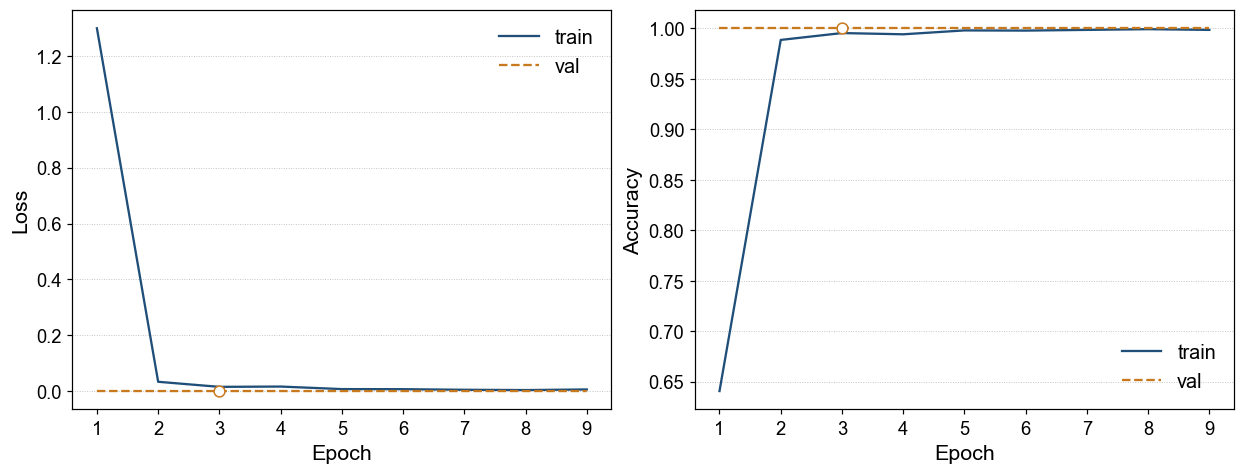

Stopped at epoch 9, restored weights from epoch 3.

In [4]:
hist = pd.read_csv(RES / "history" / "clean-seed42.csv")
best_epoch = int(hist.loc[hist.val_loss.idxmin(), "epoch"])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), layout="constrained")
axes[0].plot(hist.epoch, hist.loss, color=NAVY, label="train")
axes[0].plot(hist.epoch, hist.val_loss, color=ACCENT, linestyle="--", label="val")
axes[0].scatter([best_epoch], [hist.val_loss.min()], facecolor="white",
                 edgecolor=ACCENT, zorder=5, s=50)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(hist.epoch, hist.accuracy, color=NAVY, label="train")
axes[1].plot(hist.epoch, hist.val_accuracy, color=ACCENT, linestyle="--", label="val")
best_val_acc = float(hist.loc[hist.val_loss.idxmin(), "val_accuracy"])
axes[1].scatter([best_epoch], [best_val_acc], facecolor="white",
                 edgecolor=ACCENT, zorder=5, s=50)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="0.75")
plt.show()

display(Markdown(f"Stopped at epoch {int(hist.epoch.max())}, restored weights from epoch {best_epoch}."))

## Confusion matrices

Every cell annotated, including zeros.

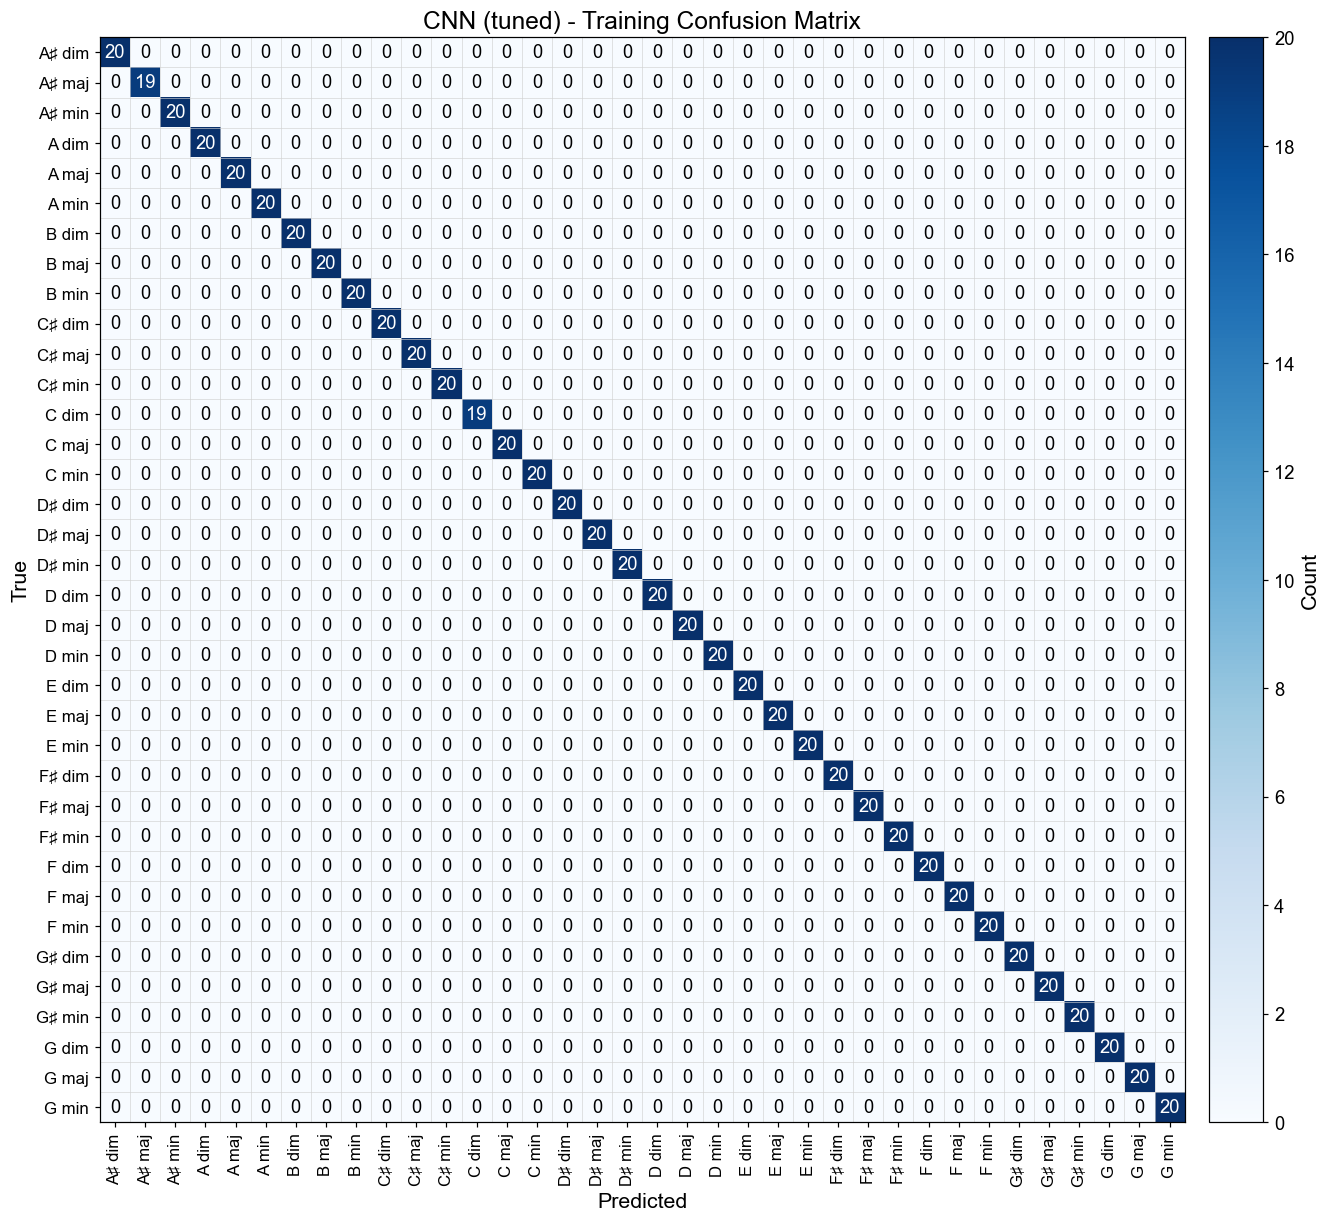

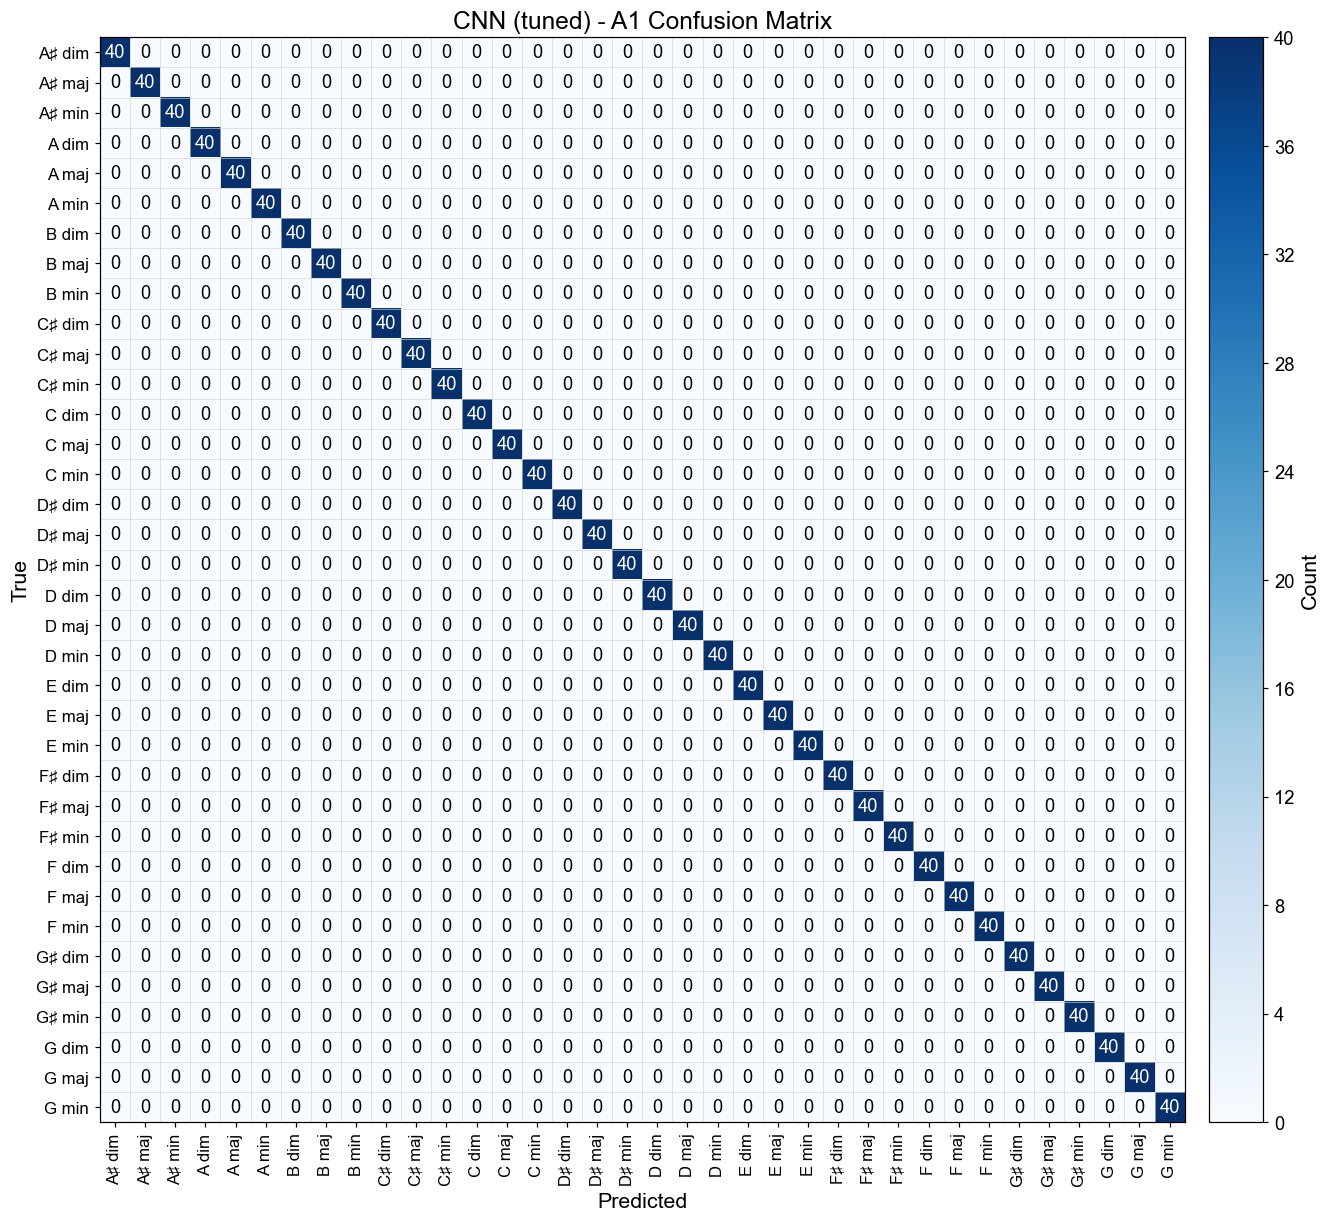

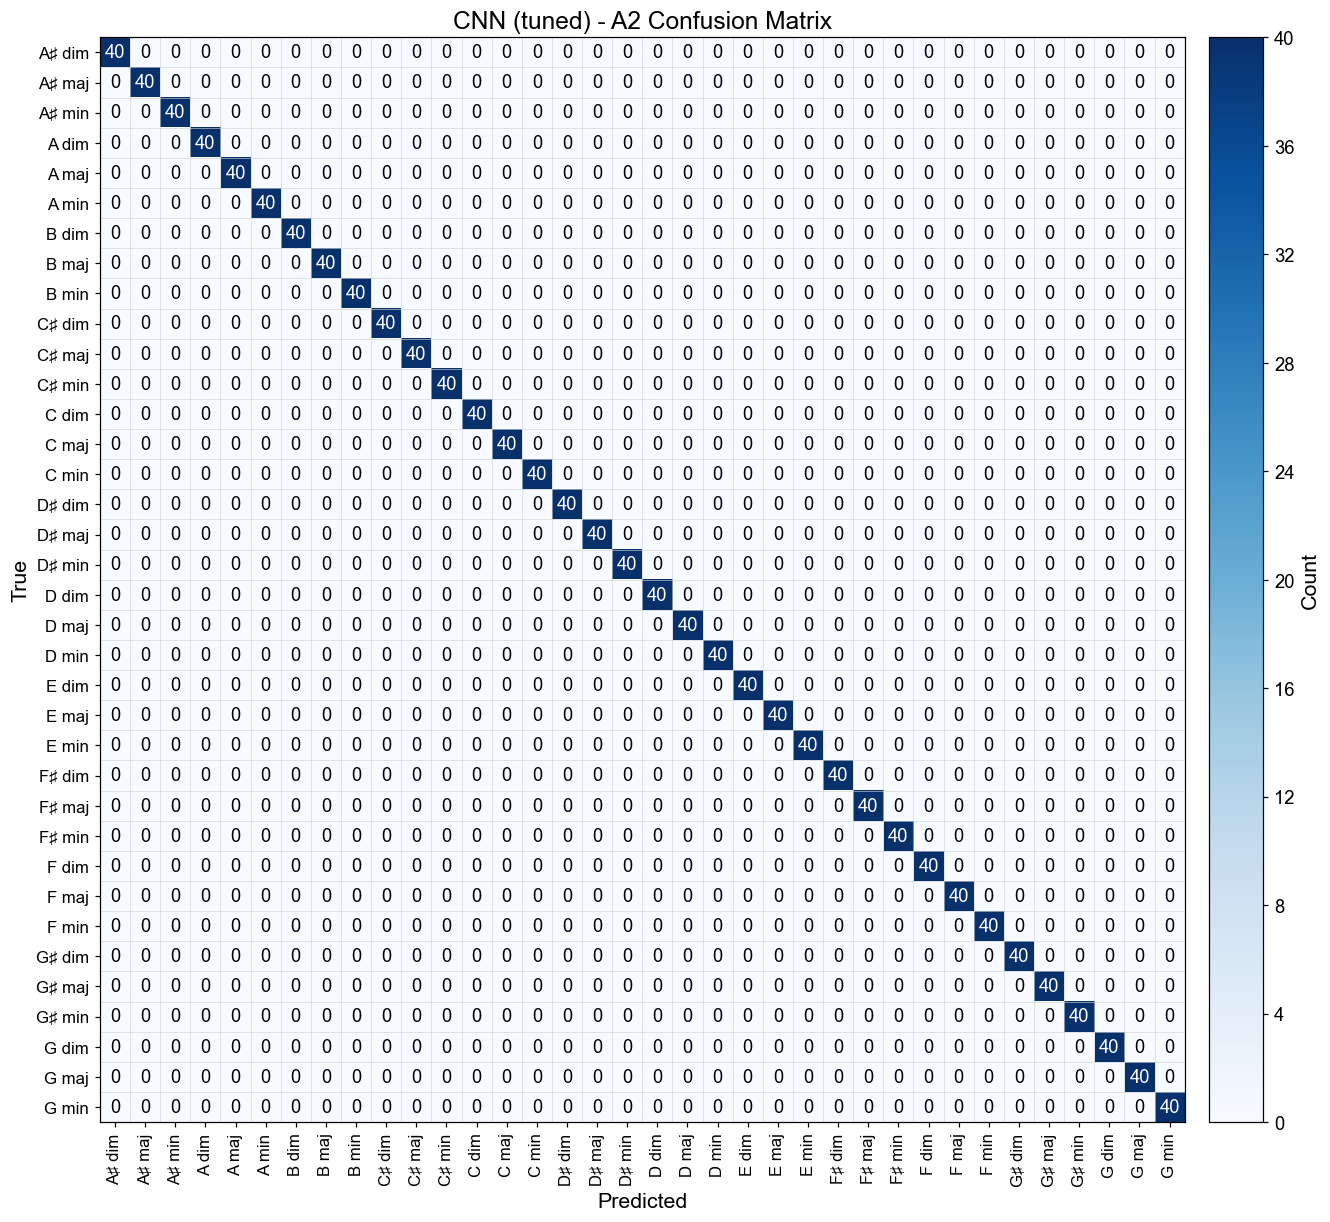

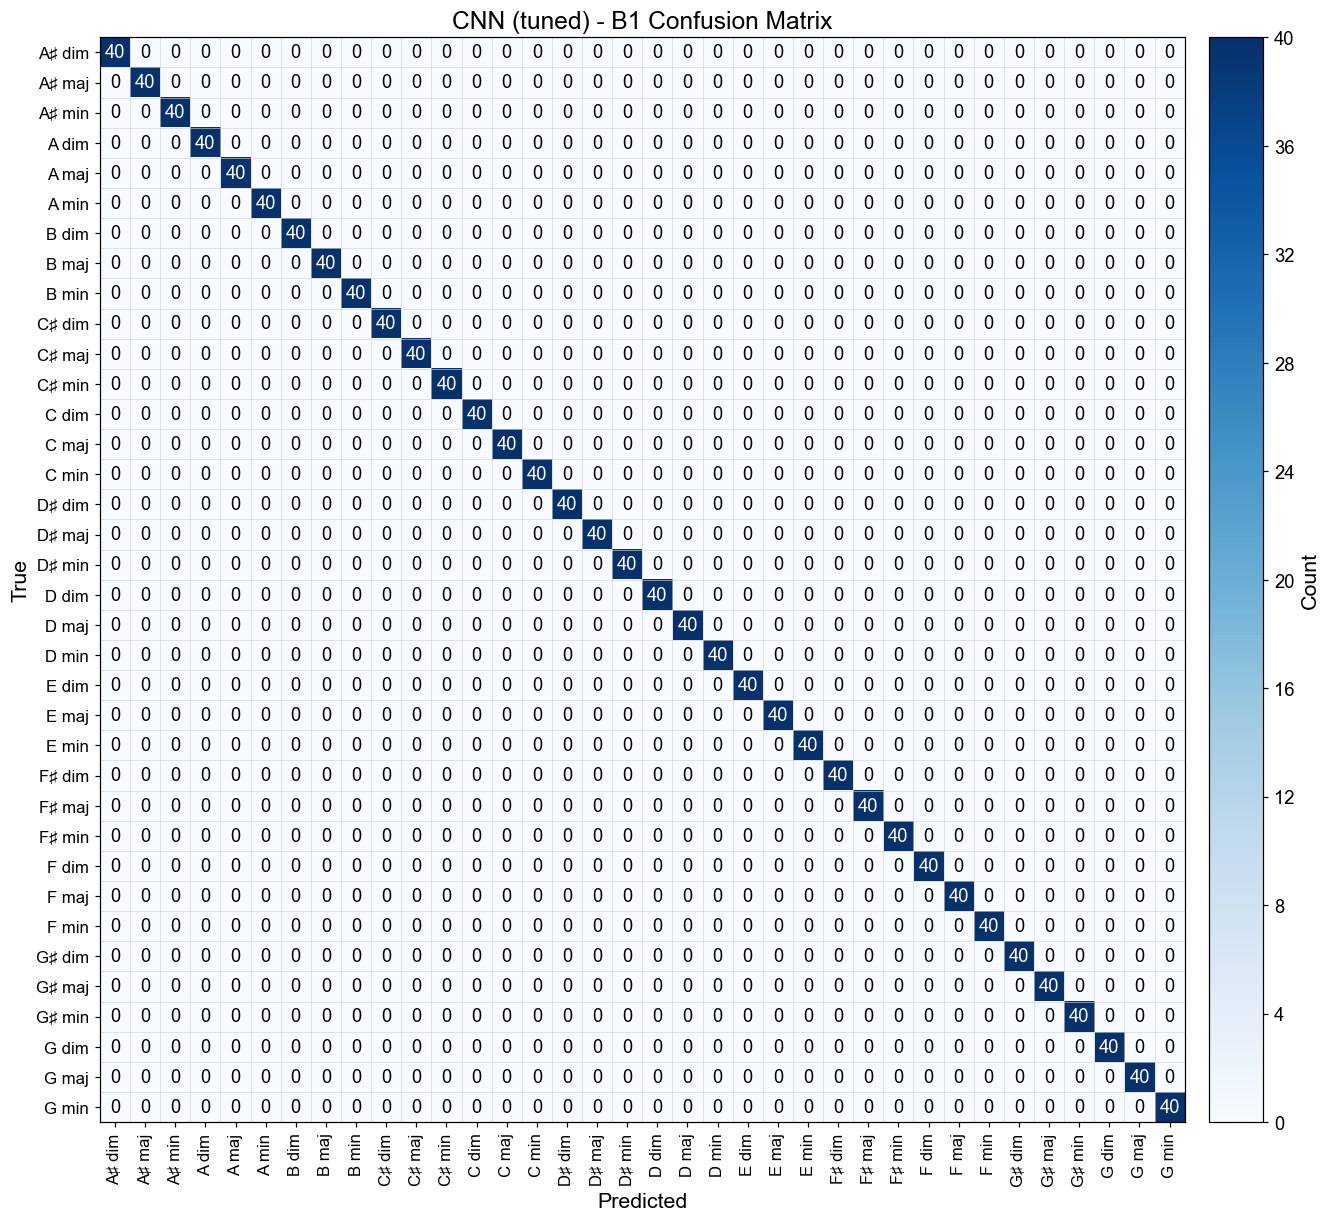

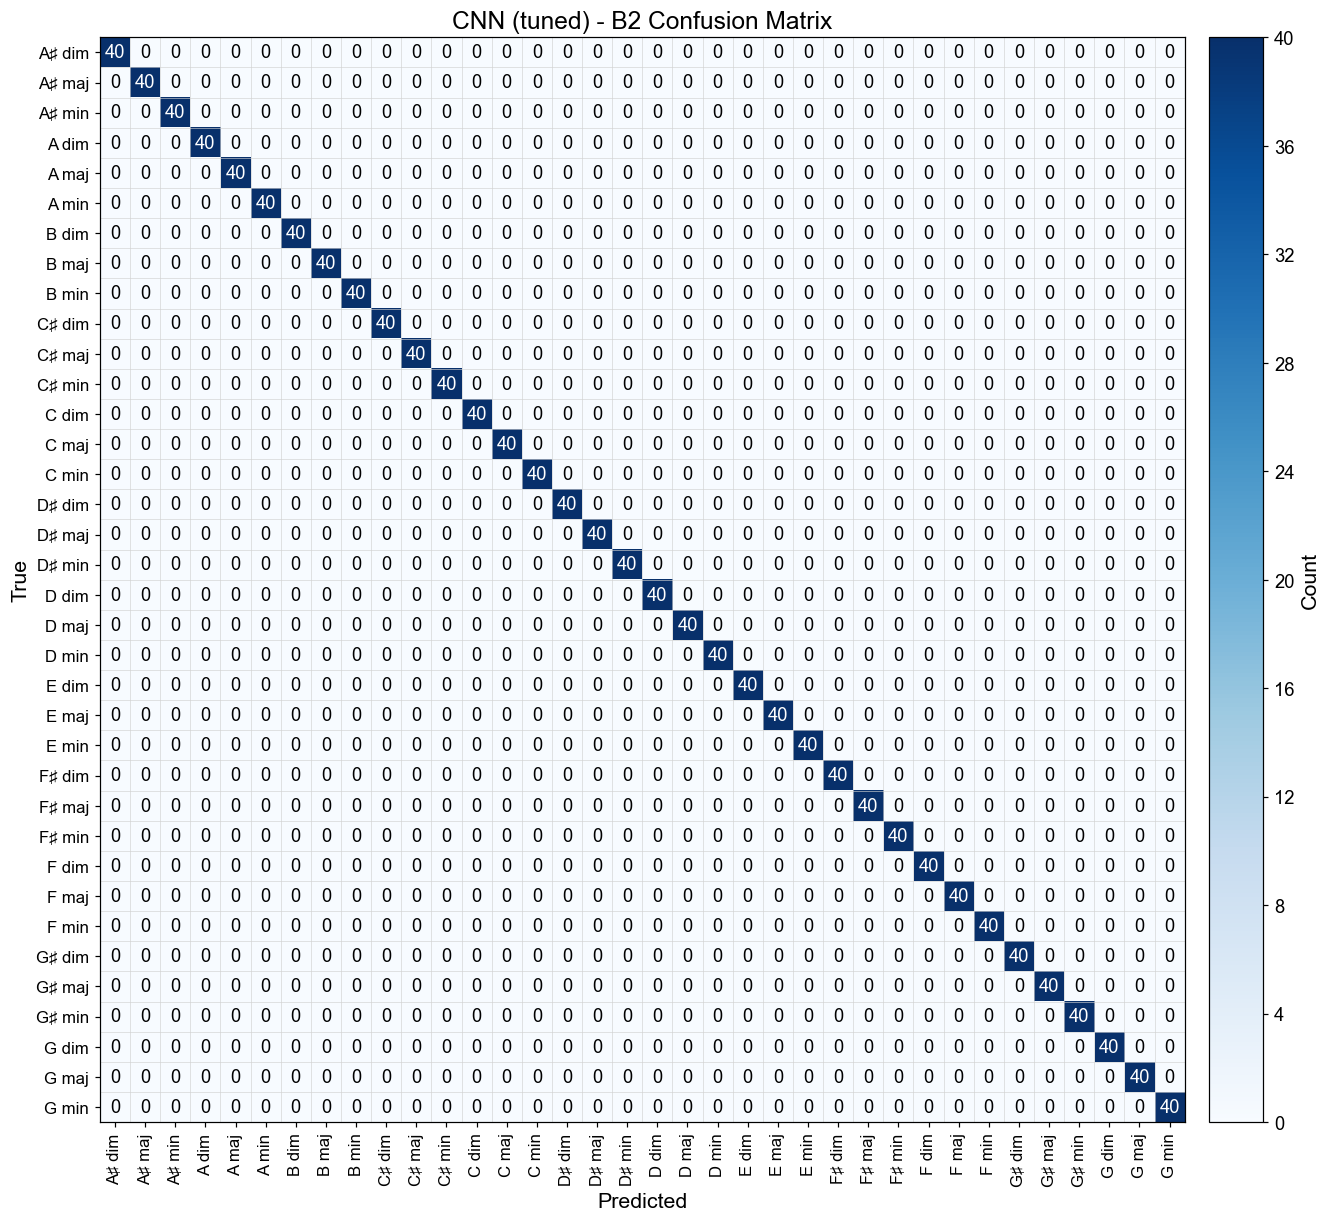

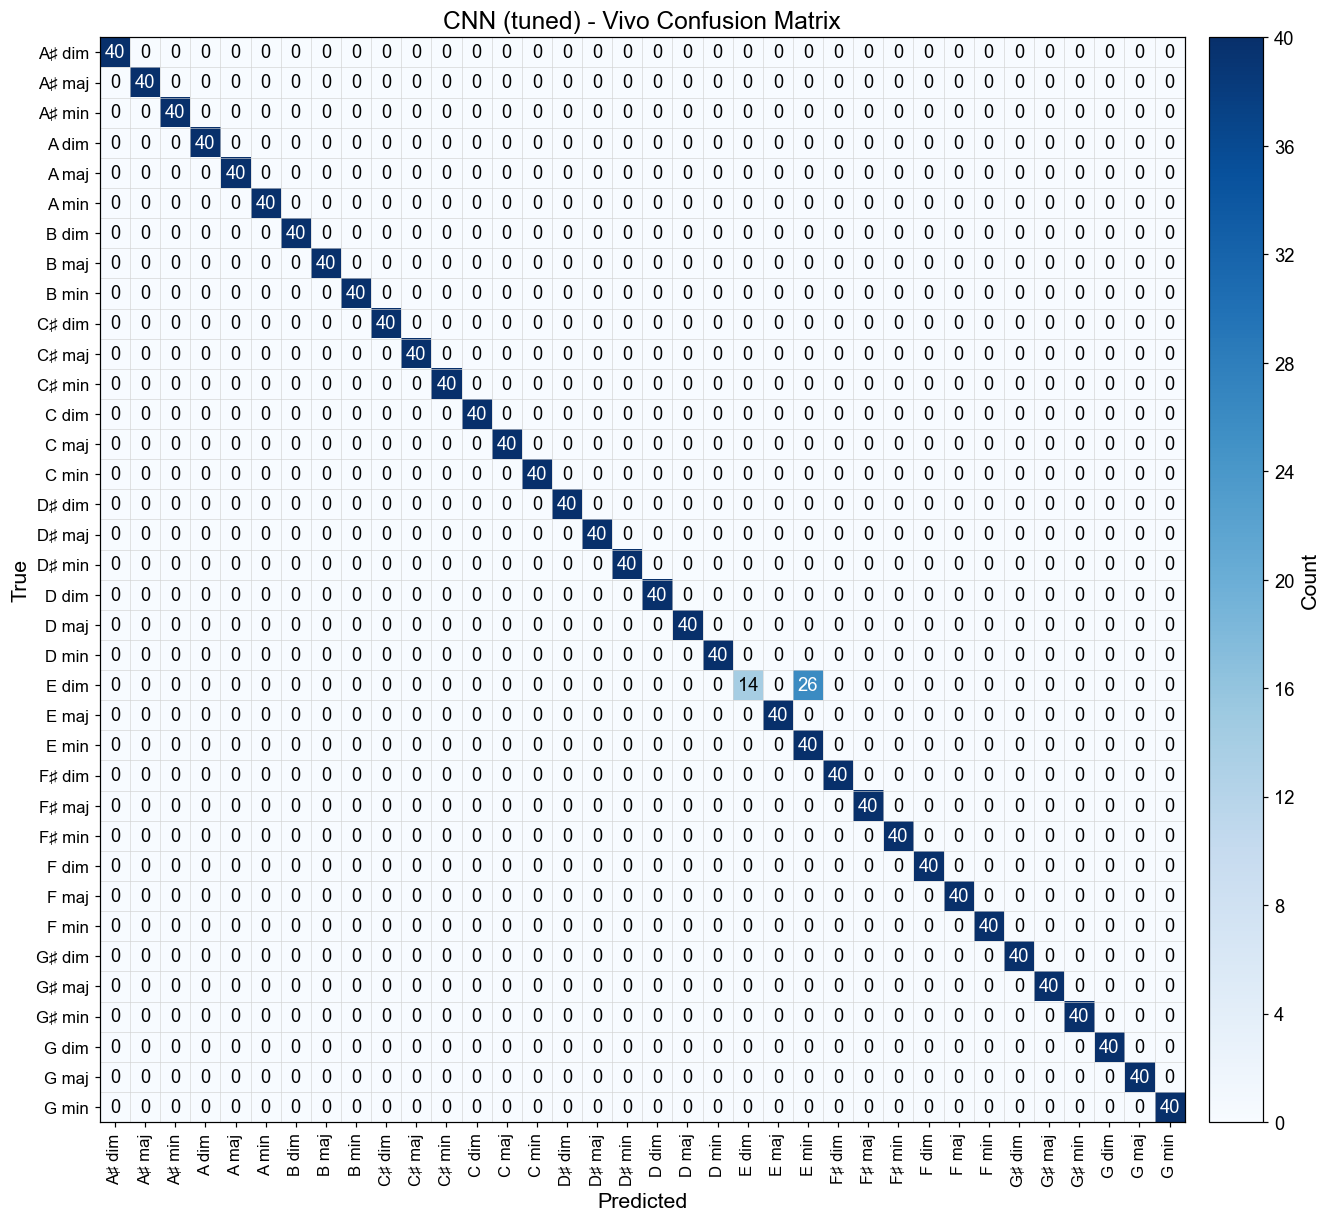

In [5]:
names = class_names()
show_cm("training", *training_cm())
for ds in OOD:
    cm = load_cm(ds)
    show_cm(ds, cm.loc[names, names].to_numpy(dtype=float), names)

## Evaluation metrics

Macro precision, recall, and F1 from the confusion matrices above. Mean and
std are over the OOD rows only (training excluded, since it is not a
generalization measurement).

In [6]:
names = class_names()
rows = []
PER_CLASS = {}
items = [("training", *training_cm())]
for ds in OOD:
    cm = load_cm(ds)
    items.append((ds, cm.loc[names, names].to_numpy(dtype=float), names))
for ds, mat, cls in items:
    per_class, summary = metrics_from_cm(mat, cls)
    PER_CLASS[ds] = per_class
    rows.append({"evaluation": LABEL[ds], **summary})

full_df = pd.DataFrame(rows)
ood_only = full_df[full_df.evaluation != "Training"].reset_index(drop=True)
summary_df = with_mean_std(ood_only, "evaluation")
summary_df = pd.concat([full_df[full_df.evaluation == "Training"], summary_df], ignore_index=True)
display(Markdown("### Recorded evaluations"))
display(summary_df.round(4))

### Recorded evaluations

,evaluation,accuracy,precision,recall,f1-score
0,Training,1.0000,1.0000,1.0000,1.0000
1,A1,1.0000,1.0000,1.0000,1.0000
2,A2,1.0000,1.0000,1.0000,1.0000
3,B1,1.0000,1.0000,1.0000,1.0000
4,B2,1.0000,1.0000,1.0000,1.0000
5,Vivo,0.9819,0.9891,0.9819,0.9798
6,mean,0.9964,0.9978,0.9964,0.9960
7,std,0.0081,0.0049,0.0081,0.0090


## Per-class metrics

Only classes with accuracy below 1.0.

In [7]:
cols = ["class", "precision", "recall", "f1-score", "accuracy", "support"]
for ds in OOD:
    pc = PER_CLASS[ds]
    weak = pc.loc[pc.accuracy < 1.0, cols].sort_values("accuracy").reset_index(drop=True)
    display(Markdown(f"**{LABEL[ds]}**"))
    if weak.empty:
        display(pd.DataFrame([{"note": "every class has accuracy 1.0"}]))
    else:
        display(weak.round(4))

**A1**

,note
0,every class has accuracy 1.0


**A2**

,note
0,every class has accuracy 1.0


**B1**

,note
0,every class has accuracy 1.0


**B2**

,note
0,every class has accuracy 1.0


**Vivo**

,class,precision,recall,f1-score,accuracy,support
0,E dim,1.0,0.35,0.5185,0.35,40
